In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arshkon/linkedin-job-postings/postings.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/companies.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/company_industries.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/company_specialities.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/companies/employee_counts.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/mappings/industries.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/mappings/skills.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/benefits.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/job_skills.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/job_industries.csv
/kaggle/input/datasets/arshkon/linkedin-job-postings/jobs/salaries.csv


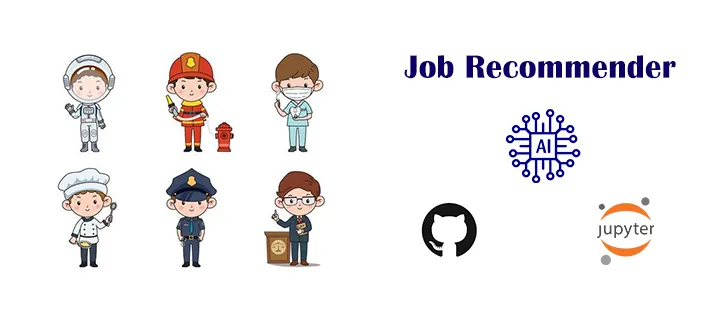

# AI-Powered Job Recommendation System

## Project Overview

Finding relevant job opportunities among thousands of job postings can be challenging for job seekers. This project develops a content-based recommendation system that matches a user's skills and interests with suitable job opportunities.

Using natural language processing (NLP) techniques, job descriptions are transformed into numerical representations and compared with a user profile. The system then ranks jobs based on similarity and recommends the most relevant opportunities.

### Objectives

* Analyze real-world LinkedIn job posting data
* Create a user profile based on skills and interests
* Apply NLP techniques for text representation
* Build a content-based recommendation engine
* Generate personalized job recommendations


## Step 1: Import Required Libraries

This project uses Pandas for data manipulation and Scikit-learn for text processing and similarity calculations. These libraries provide the core functionality required to build a content-based recommendation system.

In [50]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Step 2: Load the LinkedIn Job Postings Dataset

The dataset contains over 120,000 job postings collected from LinkedIn. It includes information such as job titles, descriptions, locations, experience levels, and salary information.

The first step is to load the dataset and inspect its structure.


In [51]:
jobs = pd.read_csv('/kaggle/input/datasets/arshkon/linkedin-job-postings/postings.csv')
jobs.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [52]:
jobs.columns

Index(['job_id', 'company_name', 'title', 'description', 'max_salary',
       'pay_period', 'location', 'company_id', 'views', 'med_salary',
       'min_salary', 'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code', 'fips'],
      dtype='object')

## Step 3: Initial Data Exploration

Before building a recommendation system, it is important to understand the available features and identify which columns are useful for matching users with jobs.

For this project, job titles and descriptions are the most valuable sources of information because they contain details about required skills, responsibilities, and qualifications.


In [53]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

- Many columns have almost all missing values. Only some rows contain information.
Since there are more than 123,000 jobs, we won't use the columns that have missing values.

- description: contains rich information for nearly every job. This is actually better for NLP.

In [55]:
jobs.isnull().sum()

job_id                             0
company_name                    1719
title                              0
description                        7
max_salary                     94056
pay_period                     87776
location                           0
company_id                      1717
views                           1689
med_salary                    117569
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                108603
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0
currency                       87776
c

## Step 4: Select Relevant Features

Many columns in the dataset are not necessary for generating recommendations.

For a content-based recommendation system, the most important information comes from job titles and job descriptions. These fields capture the skills, responsibilities, and qualifications required for each role.

To simplify the analysis, only the relevant columns are retained.


In [56]:
jobs = jobs[['company_name','title', 'description']]

In [57]:
jobs[['title','description']].sample(3)
jobs.head()

,company_name,title,description
0,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...
1,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ..."
2,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...
3,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...
4,NaN,Service Technician,Looking for HVAC service tech with experience ...


In [58]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   company_name  122130 non-null  object
 1   title         123849 non-null  object
 2   description   123842 non-null  object
dtypes: object(3)
memory usage: 2.8+ MB


In [59]:
jobs.columns

Index(['company_name', 'title', 'description'], dtype='object')

## Step 5: Data Cleaning

Machine learning models cannot process missing text values. Therefore, any rows with missing job descriptions are removed.

This ensures that every job posting contains enough information for recommendation generation.


In [60]:
jobs = jobs.dropna()
jobs.shape

(122124, 3)

In [61]:
jobs.isnull().sum()

company_name    0
title           0
description     0
dtype: int64

## Step 6: Create a User Profile

To generate personalized recommendations, the system requires information about the user's skills and interests.

For demonstration purposes, a sample user profile is created based on skills commonly associated with data science and analytics roles. The recommendation engine will compare this profile against job descriptions and identify the most relevant opportunities.

In [62]:
user_profile = """
Python
SQL
Machine Learning
Data Analysis
Data Visualization
Power BI
Forecasting
Statistics
Scikit-learn
"""

## Step 7: Transform Text into Numerical Features Using TF-IDF

Machine learning algorithms cannot work directly with text data. Therefore, job descriptions and user profiles must be converted into numerical representations.

TF-IDF (Term Frequency-Inverse Document Frequency) is a commonly used Natural Language Processing (NLP) technique that measures the importance of words within a collection of documents.

This transformation allows the recommendation system to compare the user's skills with job descriptions mathematically and identify the most relevant opportunities.


In [63]:
vectorizer = TfidfVectorizer(
    stop_words='english'
)

job_vectors = vectorizer.fit_transform(
    jobs['description']
)

print(job_vectors.shape)

(122124, 380221)


## Step 8: Transform the User Profile

The user profile must be transformed using the same TF-IDF vocabulary learned from the job descriptions.

This ensures that both the user profile and job postings are represented within the same feature space, allowing meaningful similarity calculations.


In [64]:
user_vector = vectorizer.transform(
    [user_profile]
)

print(user_vector.shape)

(1, 380221)


## Step 9: Calculate Similarity Scores

Cosine Similarity is used to measure how closely the user's profile matches each job description.

The similarity score ranges from 0 to 1:

* Values closer to 1 indicate a stronger match.
* Values closer to 0 indicate a weaker match.

Jobs with the highest similarity scores will be recommended to the user.


In [65]:
similarity_scores = cosine_similarity(
    user_vector,
    job_vectors
)

print(similarity_scores.shape)

(1, 122124)


## Step 10: Rank Jobs by Similarity

After calculating similarity scores, each job posting receives a relevance score that indicates how closely it matches the user's skills and interests.

The jobs are then ranked from highest to lowest similarity, allowing the recommendation engine to identify the most relevant opportunities.


In [66]:
jobs['similarity_score'] = similarity_scores.flatten()

In [67]:
similarity_scores.shape

(1, 122124)

## Step 11: Generate Personalized Recommendations

Jobs are sorted according to their similarity scores. The highest-ranking positions represent the strongest matches based on the user's profile and are recommended as the most relevant opportunities.


In [68]:
recommended_jobs = jobs.sort_values(
    by='similarity_score',
    ascending=False
)

recommended_jobs.head(10)

,company_name,title,description,similarity_score
58579,Programmers.io,Power BI Developer,Note: (Open to Contract/Full-Time/Part-Time)\n...,0.424666
10642,Optomi,Power BI Developer,6 Month Contract to Hire \nJob Description: \n...,0.397325
48954,Biote,Power BI Developer,Biote Medical is the world leader in hormone o...,0.395701
6356,ZealTech,Data Analyst - Power BI & SQL,Project Type: Long Term Contract On W2 or C2CT...,0.390684
72414,Ledgent Technology,BI Analyst,Roth Staffing is looking for a Sr. BI Analyst ...,0.386700
42597,Apex Systems,Power BI Developer,Apex Systems is seeking a Software Visualizati...,0.385246
45633,R1 RCM,Power BI Developer,R1 is the leading provider of technology-drive...,0.380244
46274,Emergere Technologies LLC.,Business Intelligence Analyst,Job Title: BI AnalystLocation: Remote Duration...,0.379549
96574,Dice,Power BI Developer,Dice is the leading career destination for tec...,0.376174
10691,Odyssey Information Services,Power BI Developer,PLEASE NOTE: This position is NOT C2C/ 3rd Par...,0.375814


## Step 12 — Display Top 10 Recommendations

In [69]:
top10 = recommended_jobs[
    ['company_name', 'title', 'similarity_score']
].head(10)

top10

,company_name,title,similarity_score
58579,Programmers.io,Power BI Developer,0.424666
10642,Optomi,Power BI Developer,0.397325
48954,Biote,Power BI Developer,0.395701
6356,ZealTech,Data Analyst - Power BI & SQL,0.390684
72414,Ledgent Technology,BI Analyst,0.386700
42597,Apex Systems,Power BI Developer,0.385246
45633,R1 RCM,Power BI Developer,0.380244
46274,Emergere Technologies LLC.,Business Intelligence Analyst,0.379549
96574,Dice,Power BI Developer,0.376174
10691,Odyssey Information Services,Power BI Developer,0.375814


In [70]:
top10 = recommended_jobs[
    ['company_name', 'title', 'similarity_score']
].head(10)

top10['similarity_score'] = top10[
    'similarity_score'
].round(3)

top10

,company_name,title,similarity_score
58579,Programmers.io,Power BI Developer,0.425
10642,Optomi,Power BI Developer,0.397
48954,Biote,Power BI Developer,0.396
6356,ZealTech,Data Analyst - Power BI & SQL,0.391
72414,Ledgent Technology,BI Analyst,0.387
42597,Apex Systems,Power BI Developer,0.385
45633,R1 RCM,Power BI Developer,0.380
46274,Emergere Technologies LLC.,Business Intelligence Analyst,0.380
96574,Dice,Power BI Developer,0.376
10691,Odyssey Information Services,Power BI Developer,0.376


**How does the recommendation system work?**

The system uses TF-IDF vectorization to convert job descriptions and a user skill profile into numerical representations. Cosine Similarity is then used to measure how closely each job matches the user's skills. Jobs are ranked by similarity score and the highest-ranking positions are returned as personalized recommendations.

## Visualization of Top Recommended Jobs

The following chart displays the highest-ranked job recommendations generated by the recommendation engine. Higher similarity scores indicate stronger alignment between the user's profile and job requirements.

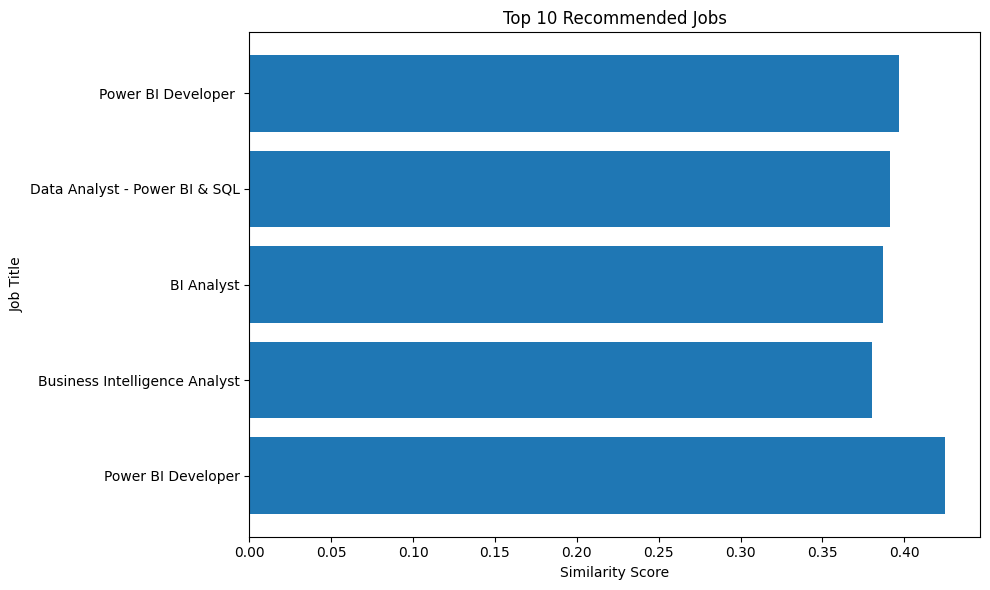

In [71]:
import matplotlib.pyplot as plt

top10_plot = top10.sort_values(
    by='similarity_score'
)

plt.figure(figsize=(10,6))

plt.barh(
    top10_plot['title'],
    top10_plot['similarity_score']
)

plt.xlabel('Similarity Score')
plt.ylabel('Job Title')
plt.title('Top 10 Recommended Jobs')

plt.tight_layout()
plt.show()

## Conclusion

The recommendation system successfully matched a user profile with relevant job opportunities using NLP techniques.

Key observations:

* TF-IDF was used to transform textual job descriptions into numerical representations.
* Cosine Similarity measured how closely each job matched the user's skills and interests.
* The system identified data-related roles such as Power BI Developer, BI Analyst, and Data Analyst as the strongest matches.
* Results demonstrate how recommendation systems can support personalized job discovery and career matching.
* This project provides a simple but effective example of applying Natural Language Processing and machine learning techniques to real-world recruitment and job recommendation scenarios.


## Additional Analysis: Filtering for Data Science and Machine Learning Roles

To improve the relevance of recommendations, the dataset can be filtered to focus specifically on data science, machine learning, and analytics-related positions.

This reduces noise from unrelated roles and provides recommendations that are more aligned with the user's career goals.

In [72]:
ds_jobs = jobs[
    jobs['title'].str.contains(
        'Data|Machine Learning|AI|Analytics|Scientist|Analyst',
        case=False,
        na=False
    )
].copy()

print(ds_jobs.shape)

(15856, 4)


- Now recreate the vectors.

In [73]:
vectorizer_ds = TfidfVectorizer(
    stop_words='english'
)

job_vectors_ds = vectorizer_ds.fit_transform(
    ds_jobs['description']
)

user_vector_ds = vectorizer_ds.transform(
    [user_profile]
)

similarity_scores_ds = cosine_similarity(
    user_vector_ds,
    job_vectors_ds
)

ds_jobs['similarity_score'] = similarity_scores_ds.flatten()

In [74]:
top_ds_jobs = ds_jobs.sort_values(
    by='similarity_score',
    ascending=False
)

top_ds_jobs[
    ['company_name','title','similarity_score']
].head(10)

,company_name,title,similarity_score
6356,ZealTech,Data Analyst - Power BI & SQL,0.372887
46274,Emergere Technologies LLC.,Business Intelligence Analyst,0.359953
72414,Ledgent Technology,BI Analyst,0.352306
101245,CCS Global Tech,Business Intelligence Analyst,0.346009
96549,Dice,BI Analyst,0.345758
5715,Ascentt,Senior Data Scientist - Forecasting,0.345146
24895,FUSTIS LLC,Data Scientist (Human Services experience),0.321835
116439,Confidential Jobs,Lead Machine Learning Engineer,0.317051
57724,"TSR Consulting Services, Inc.",Senior Data Engineer,0.308295
46518,PCS Wireless,Business Intelligence Analyst,0.308225


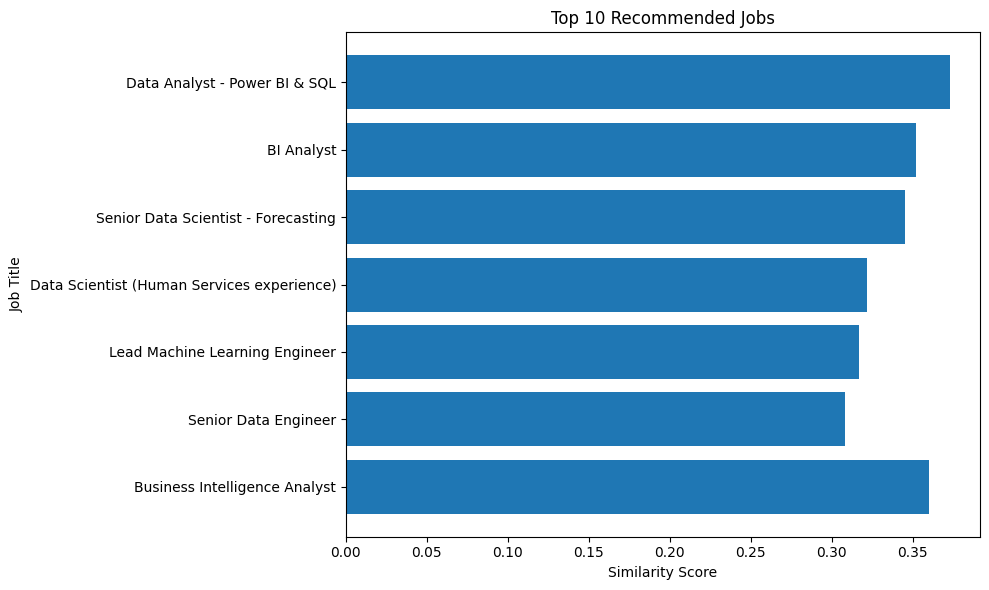

In [75]:
import matplotlib.pyplot as plt

top10_plot2 = top_ds_jobs.head(10).sort_values(
    by='similarity_score'
)

plt.figure(figsize=(10,6))

plt.barh(
    top10_plot2['title'],
    top10_plot2['similarity_score']
)

plt.xlabel('Similarity Score')
plt.ylabel('Job Title')
plt.title('Top 10 Recommended Jobs')

plt.tight_layout()
plt.show()